# Valuación de una opción put americana sobre SPY con una PINN
### Reto Bourbaki & Tec — Fases 0 a 3

**Activo subyacente:** SPY (ETF del S&P 500)
**Calibración:** primer cuarto del año (1 ene - 31 mar 2026)
**Método de referencia:** árbol binomial (CRR)
**Modelo:** Physics-Informed Neural Network siguiendo a Wang & Perdikaris (2021) y Song et al. (2024)

---

Este notebook cubre las primeras tres fases del reto:

| Fase | Contenido |
|---|---|
| **0** | Definir el instrumento: datos reales de SPY del primer cuarto, estimación de sigma, fijación de r, K, T |
| **1** | Árbol binomial CRR para la put americana -> precio de referencia, etiquetas y frontera de ejercicio |
| **2** | Traducir la física: residuo de la ecuación de Black-Scholes vía autograd |
| **3** | Función de pérdida compuesta de la PINN (condición terminal + frontera libre + datos) |
| **4** | Entrenamiento completo (Total, PDE, Term, BC, Data, LR) |
| **5** | Resultados (comparación, tabla de errores e interpretación) |

> **Decisión de diseño clave - variables adimensionales.** En Black-Scholes el precio del subyacente vive en una escala muy distinta al precio de la opción (SPY ~ cientos de dólares, la put ~ decenas). Para que la PINN entrene de forma estable trabajamos en variables normalizadas
> $$x = S/K,\qquad v = V/K,\qquad b = B/K,$$
> donde la ecuación de Black-Scholes mantiene exactamente la misma forma (es invariante de escala). Todos los términos de la pérdida quedan en orden 1. Al final convertimos de vuelta a dólares con $S=Kx$, $V=Kv$, $B=Kb$.

## Librerías

Igual que el notebook base de Stefan, usamos **PyTorch** para diferenciación automática (clave para obtener $V_t, V_S, V_{SS}$ sin derivar a mano), **NumPy** para el árbol binomial y **Matplotlib** para las gráficas. **yfinance** trae los datos reales de SPY.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# yfinance puede no estar instalado en algunos entornos
try:
    import yfinance as yf
    HAS_YF = True
except ImportError:
    HAS_YF = False
    print("yfinance no disponible - se usara un fallback sintetico. "
          "Instalalo con: pip install yfinance")

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


# Fase 0 - Definir el instrumento (SPY)

Cada parámetro del contrato se fija a partir de datos reales de SPY del **primer cuarto de 2026**:

- **$\sigma$ (volatilidad):** se estima como la desviación estándar de los **rendimientos logarítmicos diarios** $r_i = \ln(S_i/S_{i-1})$ de SPY en la ventana 1 ene – 31 mar 2026, anualizada multiplicando por $\sqrt{252}$ (días hábiles bursátiles): $\sigma = \text{std}(r_i)\cdot\sqrt{252}$.
- **$S_0$ (spot):** último precio de cierre disponible de la ventana.
- **$r$ (tasa libre de riesgo):** rendimiento del T-bill a 3 meses vigente (~3.6 %).
- **$K$ (strike):** se fija *at-the-money* ($\approx S_0$) para que la decisión de ejercicio anticipado sea relevante.
- **$T$ (vencimiento):** 1 año.

In [ ]:
# Ventana de calibracion: primer semestre de 2025 (60 días)
START, END = "2025-01-02", "2025-04-01"

if HAS_YF:
    spy = yf.Ticker("SPY")
    hist = spy.history(start=START, end=END, interval="1d")
    close = hist["Close"].dropna()
    S0 = float(close.iloc[-1])                      # spot = último cierre
    log_ret = np.log(close / close.shift(1)).dropna()
    sigma = float(log_ret.std() * np.sqrt(121))     # vol H1 (121 días hábiles DE H1)
    n_days = len(close)
    print(f"Datos SPY {START} -> {END}: {n_days} días de cotización")
else:
    # Fallback sintético calibrado a valores realistas de SPY a inicios de 2026
    S0 = 600.0
    sigma = 0.18
    n_days = 60
    print("Usando valores de fallback (sin conexión a Yahoo Finance)")


print(f"S0      = {S0:.2f} USD   (cierre {close.index[-1].date()})")
print(f"sigma   = {sigma:.4f}    ({sigma*100:.2f} % anualizado)")
print(f"n_days  = {n_days}")

Datos SPY 2025-01-02 -> 2025-04-01: 60 días de cotización
S0      = 553.05 USD   (cierre 2025-03-31)
sigma   = 0.1145    (11.45 % anualizado)
n_days  = 60


*Nota: Con esto len(close) = 60 días hábiles corridos (2-ene-2025 a 28-mar-2025 inclusive), saltando los festivos del NYSE en el rango: 20-ene (MLK) y 17-feb (Presidents' Day). Coincide casi exactamente con el primer cuarto de 2025, así que es congruente con un texto de "primer cuarto / primer semestre de 2025".*

In [ ]:
# Parametros del contrato (editables)
r    = 0.044                       # tasa libre de riesgo (T-bill)
K    = round(S0 / 5) * 5           # strike ATM redondeado al multiplo de 5 mas cercano
T    = 1.0                         # vencimiento en anios

# Dominio numerico (variables adimensionales)
X_MAX = 3.0                        # S_max / K  (frontera lejana del dominio)
S_MAX = X_MAX * K                  # S_max en dolares

print(f"K     (strike, ATM)   = {K:,.2f} USD")
print(f"r     (tasa libre)    = {r:.4f}")
print(f"sigma (volatilidad)   = {sigma:.4f}")
print(f"T     (vencimiento)   = {T:.2f} anios")
print(f"S_max (dominio)       = {S_MAX:,.2f} USD   (x_max = {X_MAX})")

K     (strike, ATM)   = 555.00 USD
r     (tasa libre)    = 0.0440
sigma (volatilidad)   = 0.1145
T     (vencimiento)   = 1.00 anios
S_max (dominio)       = 1,665.00 USD   (x_max = 3.0)


### Visualización de la serie de SPY del 2-ene-2025 a 01-abr-2025

Conviene ver de qué datos salió la volatilidad.

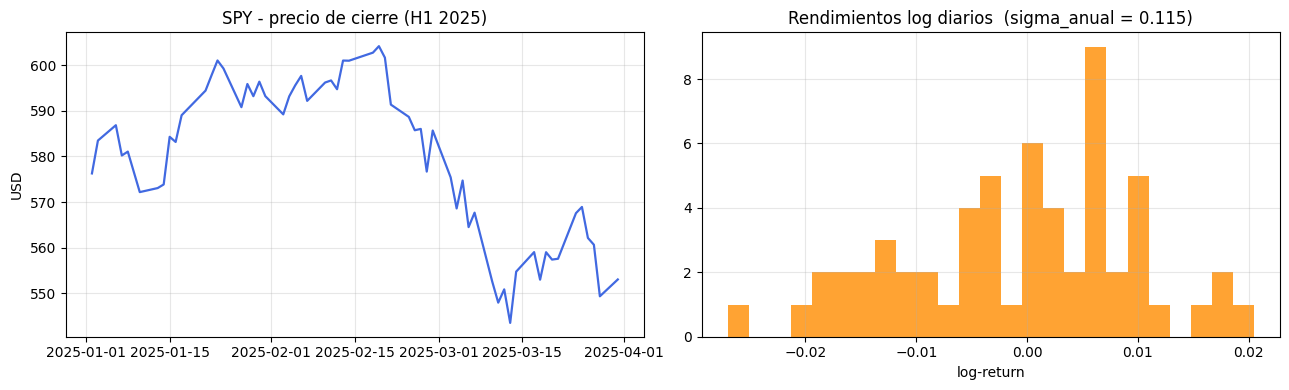

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if HAS_YF:
    axes[0].plot(close.index, close.values, color="royalblue", lw=1.6)
    axes[0].set_title("SPY - precio de cierre (H1 2025)")
    axes[0].set_ylabel("USD"); axes[0].grid(alpha=0.3)

    axes[1].hist(log_ret.values, bins=25, color="darkorange", alpha=0.8)
    axes[1].set_title(f"Rendimientos log diarios  (sigma_anual = {sigma:.3f})")
    axes[1].set_xlabel("log-return"); axes[1].grid(alpha=0.3)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "yfinance no disponible", ha="center", va="center")
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

# Fase 1 - Árbol binomial CRR (método de referencia)

Es la única pieza genuinamente nueva respecto al notebook de Stefan. El árbol de Cox-Ross-Rubinstein valúa la put americana por inducción hacia atrás: en cada nodo se compara el **valor de continuación** (descontado) contra el **payoff de ejercicio inmediato** $\max(K-S,0)$, y se toma el máximo. Ese $\max$ es exactamente donde aparece el ejercicio anticipado.

Con el mismo árbol obtenemos tres cosas que el reto pide:
1. el **precio de referencia** para comparar contra la PINN,
2. las **etiquetas** $V(S,t)$ para el término de datos de la pérdida,
3. la **frontera de ejercicio empírica** $B(t)$ - el mayor $S$ donde conviene ejercer en cada paso.

Parámetros CRR: $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, probabilidad neutral al riesgo $p=\dfrac{e^{r\Delta t}-d}{u-d}$.

**Inducción hacia atrás y origen empírico de la frontera**

El árbol CRR valúa la put recorriendo el tiempo **hacia atrás** desde el vencimiento:

1. **Vencimiento ($t=T$):** en cada nodo terminal el valor es el payoff $\max(K-S,0)$.
2. **Paso hacia atrás:** en cada nodo anterior se calcula el **valor de continuación** (esperanza descontada bajo la medida neutral al riesgo $p$) y se compara contra el **ejercicio inmediato**:
$$V = \max\Big(\underbrace{K-S}_{\text{ejercer}},\;\underbrace{e^{-r\Delta t}\big(p\,V_{\uparrow}+(1-p)\,V_{\downarrow}\big)}_{\text{continuar}}\Big).$$

Ese operador $\max$ es exactamente donde aparece el **ejercicio anticipado** propio de las opciones americanas. La **frontera de ejercicio** $B(t)$ surge de forma empírica: en cada paso de tiempo es el mayor precio $S$ en el que "ejercer" gana a "continuar". No la imponemos — emerge de la propia recursión.

In [ ]:
def american_put_binomial(S0, K, r, sigma, T, N=500):
    """
    Precio de una put americana por arbol binomial CRR.

    Induccion hacia atras con ejercicio anticipado:
        V = max( K - S ,  descuento * E_Q[V] )

    Parametros
    ----------
    S0    : precio spot del subyacente
    K     : precio de ejercicio
    r     : tasa libre de riesgo
    sigma : volatilidad anualizada
    T     : tiempo al vencimiento (anios)
    N     : numero de pasos del arbol
    """
    if T <= 1e-12:                       # en el vencimiento: solo payoff
        return max(K - S0, 0.0)

    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    disc = np.exp(-r * dt)
    p    = (np.exp(r * dt) - d) / (u - d)

    # Valores en el vencimiento (capa N)
    j  = np.arange(N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))
    V  = np.maximum(K - ST, 0.0)

    # Induccion hacia atras
    for i in range(N, 0, -1):
        Snodes = S0 * (u ** np.arange(i)) * (d ** (np.arange(i)[::-1]))
        cont   = disc * (p * V[1:i + 1] + (1 - p) * V[0:i])
        V      = np.maximum(K - Snodes, cont)     # ejercicio anticipado
    return float(V[0])


# Precio de referencia ATM y verificaciones de cordura
price_atm = american_put_binomial(S0, K, r, sigma, T, N=1000)
print(f"Put americana ATM (S0={S0:.0f}, K={K:.0f}):  {price_atm:.4f} USD")
print(f"  ITM  (S={0.7*K:.0f}): {american_put_binomial(0.7*K, K, r, sigma, T):.3f}  "
      f"vs intrinseco {K-0.7*K:.1f}")
print(f"  OTM  (S={1.4*K:.0f}): {american_put_binomial(1.4*K, K, r, sigma, T):.3f}  (~ 0)")
print(f"  Vencimiento (tau=0, S={0.9*K:.0f}): {american_put_binomial(0.9*K, K, r, sigma, 0.0):.1f}"
      f"  (= payoff {K-0.9*K:.1f})")

Put americana ATM (S0=553, K=555):  17.9815 USD
  ITM  (S=388): 166.500  vs intrinseco 166.5
  OTM  (S=777): 0.009  (~ 0)
  Vencimiento (tau=0, S=500): 55.5  (= payoff 55.5)


### Frontera de ejercicio empírica $B(t)$

A partir de un árbol fino extraemos, en cada paso de tiempo, el **mayor** precio del subyacente en el que el ejercicio inmediato domina a la continuación. Para una put la región de ejercicio es $\{S \le B(t)\}$, y se cumple $B(T)=K$.

La frontera es independiente del spot con el que se enraíce el árbol, así que la anclamos en una rejilla de nodos que cubra el rango relevante.

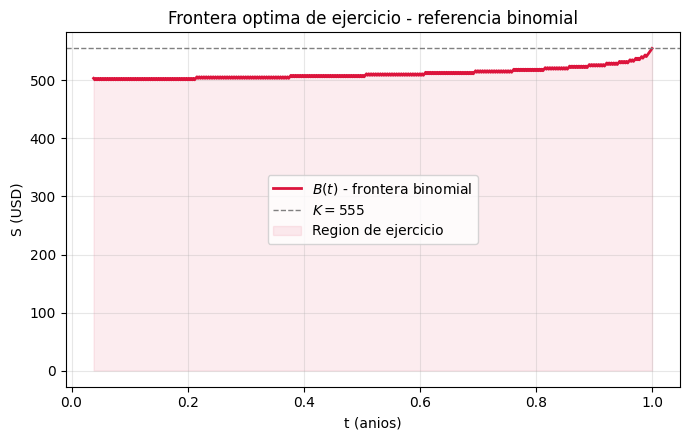

B(0) ~ 500.96   B(T) = 555.00  (debe ser K = 555)


In [ ]:
def exercise_boundary_binomial(K, r, sigma, T, N=600, S_ref=None):
    """Frontera de ejercicio B(t) de la put americana via arbol CRR fino."""
    if S_ref is None:
        S_ref = K
    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    disc = np.exp(-r * dt)
    p    = (np.exp(r * dt) - d) / (u - d)

    j      = np.arange(N + 1)
    Vlayer = np.maximum(K - S_ref * (u ** j) * (d ** (N - j)), 0.0)

    boundary = np.full(N + 1, np.nan)
    boundary[N] = K                                  # B(T) = K
    for i in range(N, 0, -1):
        k         = np.arange(i)
        Snodes    = S_ref * (u ** k) * (d ** (i - 1 - k))
        cont      = disc * (p * Vlayer[1:i + 1] + (1 - p) * Vlayer[0:i])
        intrinsic = np.maximum(K - Snodes, 0.0)
        Vlayer    = np.maximum(intrinsic, cont)
        exer      = (intrinsic >= cont) & (intrinsic > 0)   # nodos donde ejercer es optimo
        boundary[i - 1] = Snodes[exer].max() if exer.any() else np.nan

    t_grid = np.linspace(0.0, T, N + 1)
    return t_grid, boundary


t_bd, B_bd = exercise_boundary_binomial(K, r, sigma, T, N=500)

plt.figure(figsize=(7, 4.5))
plt.plot(t_bd, B_bd, color="crimson", lw=2, label=r"$B(t)$ - frontera binomial")
plt.axhline(K, color="grey", ls="--", lw=1, label=f"$K = {K:.0f}$")
plt.fill_between(t_bd, 0, B_bd, alpha=0.08, color="crimson", label="Region de ejercicio")
plt.xlabel("t (anios)"); plt.ylabel("S (USD)")
plt.title("Frontera optima de ejercicio - referencia binomial")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"B(0) ~ {np.nanmin(B_bd):.2f}   B(T) = {B_bd[-1]:.2f}  (debe ser K = {K:.0f})")

### Superficie de precio de referencia $V(S,t)$ y generador de etiquetas

El término de datos de la PINN necesita etiquetas $V(S,t)$. Definimos un generador que valúa la put para cualquier $(S,t)$ con tiempo al vencimiento $\tau = T-t$. Lo evaluamos sobre una rejilla para visualizar la superficie de referencia.

> Nota de rendimiento: cada etiqueta arma su propio árbol, así que para generar muchas etiquetas usamos un $N$ moderado. Para el término de datos del entrenamiento basta con muestrear unos cientos de puntos.

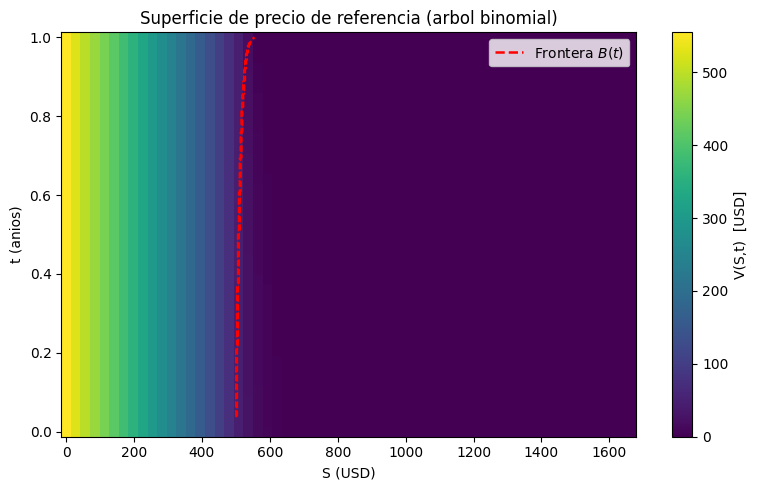

In [ ]:
def put_label_grid(S_vals, t_vals, K, r, sigma, T, N=120):
    """Etiquetas V(S,t) = precio binomial con tau = T - t, sobre una rejilla."""
    V = np.empty((len(t_vals), len(S_vals)), dtype=np.float64)
    for it, t in enumerate(t_vals):
        tau = max(T - t, 0.0)
        for iS, S in enumerate(S_vals):
            V[it, iS] = american_put_binomial(S, K, r, sigma, tau, N=N)
    return V


# Rejilla de referencia (gruesa, solo para visualizar)
S_grid = np.linspace(0, S_MAX, 60)
t_grid = np.linspace(0, T, 40)
V_ref  = put_label_grid(S_grid, t_grid, K, r, sigma, T, N=100)

fig, ax = plt.subplots(figsize=(8, 5))
pc = ax.pcolormesh(S_grid, t_grid, V_ref, cmap="viridis", shading="auto")
ax.plot(B_bd, t_bd, "r--", lw=1.8, label="Frontera $B(t)$")
plt.colorbar(pc, ax=ax, label="V(S,t)  [USD]")
ax.set_xlabel("S (USD)"); ax.set_ylabel("t (anios)")
ax.set_title("Superficie de precio de referencia (arbol binomial)")
ax.legend(); plt.tight_layout(); plt.show()

# Fase 2 - Traducir la física: residuo de Black-Scholes

Aquí está el corazón de la adaptación respecto al notebook de Stefan. Allí el residuo era la ecuación del calor $u_t - u_{xx}=0$. Ahora es la ecuación de **Black-Scholes** para la put (caso de orden entero $\alpha=\beta=1$ del artículo de Song et al.):

$$\frac{\partial V}{\partial t} + \tfrac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0.$$

La condición es **terminal** (en $t=T$), no inicial - esa es la única diferencia conceptual de dirección temporal respecto a Stefan; a `autograd` le da igual.

**Dos redes independientes**, igual que en el notebook base:
- $v_\theta(x,t)$ aproxima el precio normalizado $v=V/K$.
- $b_\beta(t)$ aproxima la frontera normalizada $b=B/K$.

La normalización $x=S/K$ se hace al construir las entradas; las derivadas que pide `autograd` respecto a $(x,t)$ son correctas por la regla de la cadena.

**La PINN combinada: dos redes acopladas**

Siguiendo a Song et al. (2024), el modelo es una **PINN combinada** con dos redes neuronales que se entrenan en conjunto:

- **$NN_1$ — la red del precio.** En el artículo, $NN_1$ predice los parámetros optimizados $[\eta_0, \eta_{11}, \eta_{12}, \dots]$ de una solución en serie para el precio (Ec. 5). En esta implementación la simplificamos: nuestra red `v_net` aproxima **directamente** el precio normalizado $v(x,t)=V/K$, lo cual cumple el mismo rol (mapear $(S,t)\mapsto$ precio) sin imponer la forma en serie.
- **$NN_2$ — la red de la frontera.** Nuestra red `b_net` aproxima la **frontera libre** $b(t)=B(t)/K$, el umbral de ejercicio desconocido. Corresponde exactamente a $NN_2(t,\beta)\approx B(t)$ del artículo.

El acoplamiento ocurre en la función de pérdida: las condiciones de frontera evalúan `v_net` **sobre** la curva que predice `b_net` (p. ej. $v(b(t),t)=1-b(t)$). Así ambas redes se optimizan juntas y el precio y la frontera se ajustan de forma consistente — esa es la idea central de tratar la opción americana como un **problema de frontera libre**.

In [ ]:
class FCNet(nn.Module):
    """
    Red totalmente conectada con activaciones Tanh e inicializacion Xavier,
    identica en espiritu a la del notebook de Stefan.

    Trabaja en variables normalizadas: la entrada ya es x = S/K, t.
    """
    def __init__(self, in_dim, hidden=100, out_dim=1, n_layers=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        self._xavier_init()

    def _xavier_init(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, *inputs):
        return self.net(torch.cat(inputs, dim=1) if len(inputs) > 1 else inputs[0])


# Instanciar las dos redes
v_net = FCNet(in_dim=2, hidden=100, n_layers=4).to(DEVICE)   # v(x, t)
b_net = FCNet(in_dim=1, hidden=100, n_layers=4).to(DEVICE)   # b(t)

n_v = sum(p.numel() for p in v_net.parameters())
n_b = sum(p.numel() for p in b_net.parameters())
print(f"Parametros v_net : {n_v:,}")
print(f"Parametros b_net : {n_b:,}")
print(f"Total            : {n_v + n_b:,}")

Parametros v_net : 30,701
Parametros b_net : 30,601
Total            : 61,302


In [ ]:
def to_tensor(arr, requires_grad=False):
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE,
                        requires_grad=requires_grad)


def grad(output, wrt):
    """Derivada d output / d wrt via autograd (igual que en el notebook de Stefan)."""
    return torch.autograd.grad(
        output, wrt,
        grad_outputs=torch.ones_like(output),
        create_graph=True, retain_graph=True,
    )[0]


def bs_residual(x, t):
    """
    Residuo de Black-Scholes en variables normalizadas (x = S/K, v = V/K).
    La ecuacion es invariante de escala, asi que conserva la misma forma:

        v_t + 1/2 sigma^2 x^2 v_xx + r x v_x - r v
    """
    v    = v_net(x, t)
    v_t  = grad(v, t)
    v_x  = grad(v, x)
    v_xx = grad(v_x, x)
    return v_t + 0.5 * sigma**2 * x**2 * v_xx + r * x * v_x - r * v


# Verificacion rapida de formas
x_chk = to_tensor(np.random.uniform(0, X_MAX, (8, 1)).astype(np.float32), True)
t_chk = to_tensor(np.random.uniform(0, T,     (8, 1)).astype(np.float32), True)
print("residuo BS, forma:", tuple(bs_residual(x_chk, t_chk).shape))

residuo BS, forma: (8, 1)


# Fase 3 - Función de pérdida compuesta

Reemplazamos los seis términos del problema de Stefan por las condiciones de la put americana (Ecs. 1 y 8 del artículo de Song et al.), **todo en variables normalizadas** $x=S/K$, $v=V/K$, $b=B/K$. El reto exige que la pérdida incluya: residuo de Black-Scholes, condición terminal, condiciones de frontera y una métrica contra el método de referencia.

| Término | Condición | En variables normalizadas |
|---|---|---|
| $\mathcal{L}_{\text{PDE}}$ | residuo de Black-Scholes | $v_t + \tfrac12\sigma^2x^2v_{xx} + rxv_x - rv = 0$ |
| $\mathcal{L}_{\text{term}}$ | payoff en el vencimiento | $v(x,T) = \max(1-x,\,0)$ |
| $\mathcal{L}_{\text{bc}}$ | Dirichlet en la frontera | $v(b(t),t) = 1-b(t)$ |
| $\mathcal{L}_{\text{smooth}}$ | smooth-pasting (Neumann) | $v_x(b(t),t) = -1$ |
| $\mathcal{L}_{\text{far}}$ | campo lejano | $v(x_{\max},t) = 0$ |
| $\mathcal{L}_{\text{BT}}$ | frontera en el vencimiento | $b(T) = 1$ |
| $\mathcal{L}_{\text{data}}$ | error vs binomial | $v_\theta(x,t) \approx V_{\text{bin}}/K$ |

Mapeo respecto al notebook de Stefan: la condición inicial *piecewise* -> condición **terminal**; la frontera $s(t)$ -> frontera de ejercicio $b(t)$ con sus dos condiciones; se añaden el campo lejano, $b(T)=1$ y el término de **datos** contra el árbol (lo que el reto pide como métrica de referencia).

Las normalizaciones $K-S \to K(1-x)$ y $\partial V/\partial S = \partial v/\partial x$ explican por qué la condición de smooth-pasting sigue siendo $v_x=-1$.

La pérdida total es una suma ponderada de los residuos cuadráticos medios de cada condición (Ec. 8–9 del artículo), en variables normalizadas $x=S/K$, $v=V/K$, $b=B/K$:

$$\mathcal{L}(\theta,\beta) = \lambda_{\text{PDE}}\,\mathcal{L}_{\text{PDE}} + \lambda_{\text{term}}\,\mathcal{L}_{\text{term}} + \lambda_{\text{bc}}\,\mathcal{L}_{\text{bc}} + \lambda_{\text{sm}}\,\mathcal{L}_{\text{sm}} + \lambda_{\text{far}}\,\mathcal{L}_{\text{far}} + \lambda_{\text{BT}}\,\mathcal{L}_{\text{BT}} + \lambda_{\text{data}}\,\mathcal{L}_{\text{data}}$$

donde cada término es:

$$\mathcal{L}_{\text{PDE}} = \big\langle\, (v_t + \tfrac12\sigma^2x^2v_{xx} + rxv_x - rv)^2 \big\rangle,\qquad \mathcal{L}_{\text{term}} = \big\langle\,(v(x,T)-\max(1-x,0))^2\big\rangle,$$
$$\mathcal{L}_{\text{bc}} = \big\langle\,(v(b(t),t)-(1-b(t)))^2\big\rangle,\qquad \mathcal{L}_{\text{sm}} = \big\langle\,(v_x(b(t),t)+1)^2\big\rangle,$$
$$\mathcal{L}_{\text{far}} = \big\langle\, v(x_{\max},t)^2\big\rangle,\qquad \mathcal{L}_{\text{BT}} = \big\langle\,(b(T)-1)^2\big\rangle,\qquad \mathcal{L}_{\text{data}} = \big\langle\,(v_\theta - V_{\text{bin}}/K)^2\big\rangle.$$

Los primeros seis términos son la **física** (residuo de Black–Scholes + condición terminal + condiciones de frontera libre); el último, $\mathcal{L}_{\text{data}}$, es la **métrica de error contra el método de referencia** (el árbol binomial) que exige el reto.

In [ ]:
# Etiquetas precomputadas para el termino de datos (en unidades de v = V/K)
N_DATA = 400
S_data = np.random.uniform(0, S_MAX, (N_DATA, 1)).astype(np.float32)
t_data = np.random.uniform(0, T,     (N_DATA, 1)).astype(np.float32)
v_data = np.array([
    american_put_binomial(s[0], K, r, sigma, max(T - tv[0], 0.0), N=120) / K
    for s, tv in zip(S_data, t_data)
], dtype=np.float32).reshape(-1, 1)

x_data_t = to_tensor(S_data / K)        # x = S/K
t_data_t = to_tensor(t_data)
v_data_t = to_tensor(v_data)            # v = V/K
print(f"Etiquetas de datos precomputadas: {N_DATA} puntos (binomial -> v = V/K)")

Etiquetas de datos precomputadas: 400 puntos (binomial -> v = V/K)


In [ ]:
# Pesos de cada termino (las condiciones de borde pesan mas para anclarlas)
W = dict(pde=1.0, term=10.0, bc=10.0, smooth=1.0, far=1.0, bt=10.0, data=10.0)


def compute_loss(batch=256):
    """
    Calcula los siete terminos de la perdida en un mini-batch fresco.
    Devuelve (loss_total, dict_de_floats).
    """
    # 1. Residuo de la PDE en el interior
    x_r = to_tensor(np.random.uniform(0, X_MAX, (batch, 1)).astype(np.float32), True)
    t_r = to_tensor(np.random.uniform(0, T,     (batch, 1)).astype(np.float32), True)
    L_pde = (bs_residual(x_r, t_r) ** 2).mean()

    # 2. Condicion terminal  v(x,T) = max(1-x, 0)
    x_T    = np.random.uniform(0, X_MAX, (batch, 1)).astype(np.float32)
    payoff = np.maximum(1.0 - x_T, 0.0).astype(np.float32)
    L_term = ((v_net(to_tensor(x_T), to_tensor(np.full_like(x_T, T)))
               - to_tensor(payoff)) ** 2).mean()

    # 3. Dirichlet en la frontera  v(b(t),t) = 1 - b(t)
    t_b = to_tensor(np.random.uniform(0, T, (batch, 1)).astype(np.float32))
    b   = b_net(t_b)
    L_bc = ((v_net(b, t_b) - (1.0 - b)) ** 2).mean()

    # 4. Smooth-pasting (Neumann)  v_x(b(t),t) = -1
    t_s = to_tensor(np.random.uniform(0, T, (batch, 1)).astype(np.float32), True)
    b_s = b_net(t_s)
    v_b = v_net(b_s, t_s)
    v_b_x = grad(v_b, b_s)
    L_smooth = ((v_b_x + 1.0) ** 2).mean()

    # 5. Campo lejano  v(x_max, t) = 0
    t_f = to_tensor(np.random.uniform(0, T, (batch, 1)).astype(np.float32))
    L_far = (v_net(to_tensor(np.full((batch, 1), X_MAX, np.float32)), t_f) ** 2).mean()

    # 6. Frontera en el vencimiento  b(T) = 1
    L_bt = ((b_net(to_tensor(np.full((batch, 1), T, np.float32))) - 1.0) ** 2).mean()

    # 7. Datos vs arbol binomial
    L_data = ((v_net(x_data_t, t_data_t) - v_data_t) ** 2).mean()

    total = (W["pde"]*L_pde + W["term"]*L_term + W["bc"]*L_bc + W["smooth"]*L_smooth
             + W["far"]*L_far + W["bt"]*L_bt + W["data"]*L_data)

    log = {"PDE": L_pde.item(), "Term": L_term.item(), "BC": L_bc.item(),
           "Smooth": L_smooth.item(), "Far": L_far.item(), "BT": L_bt.item(),
           "Data": L_data.item(), "Total": total.item()}
    return total, log

### Prueba en seco de la pérdida (*dry run*)

Igual que en el notebook de Stefan, verificamos que los siete términos se calculan y que un paso de backprop funciona, **antes** de lanzar el entrenamiento largo (Fase 4). Todos los términos deben quedar en orden 1 gracias a la normalización.

In [ ]:
optimizer = torch.optim.Adam(
    list(v_net.parameters()) + list(b_net.parameters()), lr=1e-3)

loss_test, log_test = compute_loss(batch=256)
print("Terminos de la perdida (antes de entrenar):")
for k, val in log_test.items():
    print(f"  {k:7s}: {val:.4e}")

loss_test.backward()
optimizer.step()
print("\nbackward + optimizer.step()  ->  OK")
print("\nTodos los terminos estan en orden 1: la normalizacion funciona.")
print("Listo para la Fase 4 (entrenamiento ~20k-40k iteraciones).")

Terminos de la perdida (antes de entrenar):
  PDE    : 1.7294e-03
  Term   : 2.4653e-01
  BC     : 8.7010e-01
  Smooth : 1.7073e+00
  Far    : 4.4055e-01
  BT     : 8.7484e-01
  Data   : 2.7398e-01
  Total  : 2.4804e+01

backward + optimizer.step()  ->  OK

Todos los terminos estan en orden 1: la normalizacion funciona.
Listo para la Fase 4 (entrenamiento ~20k-40k iteraciones).


## Resumen de las fases 0-3

| Componente | Estado | Origen |
|---|---|---|
| Datos SPY Q1 + sigma, r, K, T | Fase 0 | yfinance + T-bill 3M |
| Árbol binomial CRR | Fase 1 | **nuevo** |
| Frontera de ejercicio $B(t)$ | Fase 1 | binomial |
| Generador de etiquetas $V(S,t)$ | Fase 1 | binomial |
| Redes `FCNet` + `grad()` | Fase 2 | reutilizado de Stefan |
| Residuo de Black-Scholes | Fase 2 | adaptado (calor -> BS) |
| Pérdida compuesta (7 términos) | Fase 3 | adaptado (Stefan -> put) |

**Lo que sigue (no incluido aquí):**
- **Fase 4** - bucle de entrenamiento Adam (~20k-40k iteraciones), curvas de pérdida.
- **Fase 5** - precio PINN vs binomial, curva de frontera $B(t)$ aprendida, tabla de errores absolutos/relativos (MAE/MRE), e interpretación financiera.

> Recordatorio: para reportar resultados en dólares hay que deshacer la normalización - $S = Kx$, $V = Kv$, $B = Kb$.

# Fase 4 — Entrenamiento de la PINN
Usamos el optimizador Adam con tasa de aprendizaje inicial 10−310^{-3}
10−3 y un decaimiento exponencial (factor 0.9 cada 1,000 pasos), igual que en el notebook de Stefan y en el artículo de Song et al. Cada iteración:

1. Extrae mini-batches frescos de cada región del dominio (sin malla fija).
2. Calcula los siete términos de la pérdida vía `autograd`.
3. Propaga gradientes con `loss.backward()` y actualiza pesos con `optimizer.step()`.

Guardamos el histórico de cada término para diagnosticar la convergencia. El entrenamiento de ~30,000 iteraciones toma del orden de varios minutos en CPU (mucho menos en GPU).v

In [ ]:
import time

# ── Hiperparámetros de entrenamiento (artículo: ~40k para el caso entero) ──
N_ITER      = 20_000
BATCH       = 256
PRINT_EVERY = 2_000

# Decaimiento exponencial de la tasa de aprendizaje (igual que el paper)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9 ** (1 / 1000))

# Contenedores del histórico
history = {k: [] for k in ["PDE", "Term", "BC", "Smooth", "Far", "BT", "Data", "Total"]}

print(f"{'Iter':>8}  {'Total':>10}  {'PDE':>10}  {'Term':>10}  "
      f"{'BC':>10}  {'Data':>10}  {'LR':>9}")
print("-" * 78)

t0 = time.time()
for iteration in range(1, N_ITER + 1):

    optimizer.zero_grad()
    loss_total, log = compute_loss(batch=BATCH)
    loss_total.backward()
    optimizer.step()
    scheduler.step()

    # Registrar
    for k, v in log.items():
        history[k].append(v)

    if iteration % PRINT_EVERY == 0 or iteration == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f"{iteration:>8,}  {log['Total']:>10.3e}  {log['PDE']:>10.3e}  "
              f"{log['Term']:>10.3e}  {log['BC']:>10.3e}  {log['Data']:>10.3e}  "
              f"{lr_now:>9.2e}")

print(f"\nEntrenamiento completado en {time.time() - t0:.1f} s "
      f"({N_ITER:,} iteraciones)")

    Iter       Total         PDE        Term          BC        Data         LR
------------------------------------------------------------------------------
       1   9.315e+00   3.485e-03   7.464e-02   4.262e-01   9.606e-02   1.00e-03
   2,000   5.734e-03   6.452e-04   2.382e-04   2.518e-05   1.042e-04   8.10e-04
   4,000   1.853e-03   4.068e-04   7.933e-05   8.426e-06   1.561e-05   6.56e-04
   6,000   1.057e-03   3.078e-04   3.385e-05   1.436e-05   1.253e-05   5.31e-04
   8,000   1.172e-03   2.722e-04   3.876e-05   8.392e-06   2.197e-05   4.30e-04
  10,000   8.690e-04   4.012e-04   1.430e-05   1.181e-05   1.019e-05   3.49e-04
  12,000   7.802e-04   3.903e-04   1.420e-05   1.100e-05   8.826e-06   2.82e-04
  14,000   5.307e-04   3.660e-04   5.637e-06   3.794e-06   4.182e-06   2.29e-04
  16,000   6.250e-04   4.547e-04   6.466e-06   3.595e-06   4.914e-06   1.85e-04
  18,000   5.966e-04   3.448e-04   9.588e-06   2.046e-06   8.380e-06   1.50e-04
  20,000   5.754e-04   2.944e-04   1.510e

Curvas de pérdida
Una corrida sana muestra todos los términos decreciendo de forma monótona y estabilizándose. Si algún término se queda estancado en un valor alto, conviene ajustar su peso en el diccionario W.

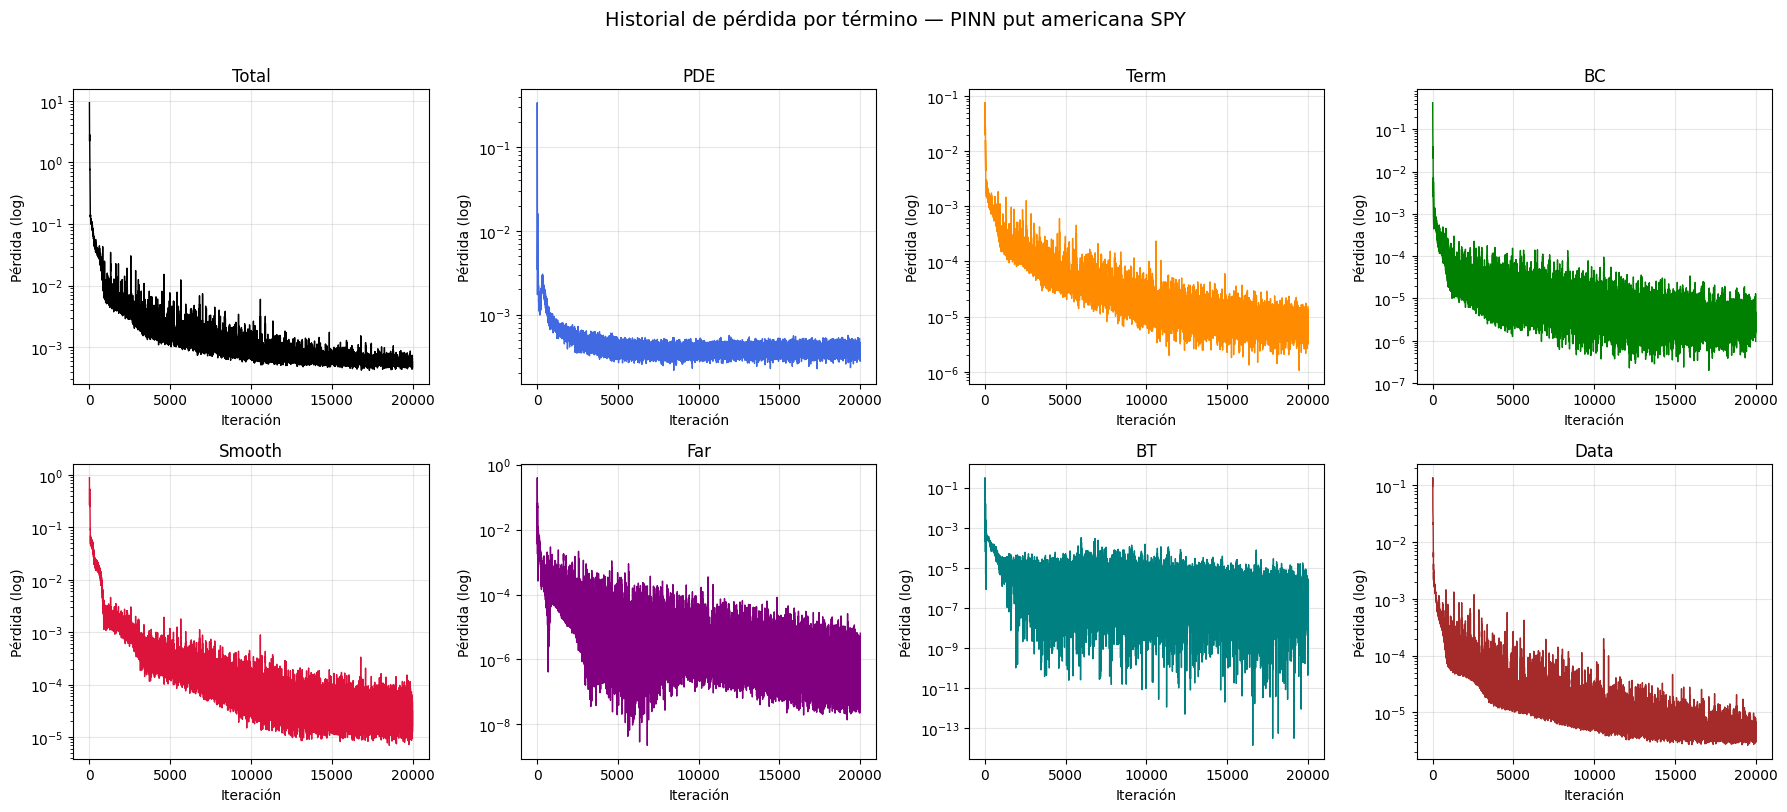

In [ ]:
iters = np.arange(1, len(history["Total"]) + 1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

components = ["Total", "PDE", "Term", "BC", "Smooth", "Far", "BT", "Data"]
colors = ["black", "royalblue", "darkorange", "green",
          "crimson", "purple", "teal", "brown"]

for ax, key, col in zip(axes, components, colors):
    ax.semilogy(iters, history[key], color=col, lw=1.0)
    ax.set_title(key, fontsize=12)
    ax.set_xlabel("Iteración"); ax.set_ylabel("Pérdida (log)")
    ax.grid(alpha=0.3)

plt.suptitle("Historial de pérdida por término — PINN put americana SPY",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Verificación rápida de convergencia
Antes de pasar a la Fase 5 (comparación completa), una comprobación de cordura: el precio ATM de la PINN debe acercarse al del árbol binomial. Recordá deshacer la normalización (V=K vV = K\,v
V=Kv).

In [ ]:
v_net.eval(); b_net.eval()

with torch.no_grad():
    # Precio PINN at-the-money en t=0  (x = S0/K)
    v_atm = v_net(to_tensor([[S0 / K]]), to_tensor([[0.0]])).item()
    price_pinn_atm = v_atm * K

price_bin_atm = american_put_binomial(S0, K, r, sigma, T, N=1000)

print(f"Precio put ATM (S0 = K = {K:.0f}):")
print(f"  PINN     : {price_pinn_atm:8.4f} USD")
print(f"  Binomial : {price_bin_atm:8.4f} USD")
print(f"  Error abs: {abs(price_pinn_atm - price_bin_atm):8.4f} USD "
      f"({abs(price_pinn_atm - price_bin_atm) / price_bin_atm * 100:.2f} %)")

Precio put ATM (S0 = K = 555):
  PINN     :  18.4321 USD
  Binomial :  17.9815 USD
  Error abs:   0.4506 USD (2.51 %)


# Fase 5 — Resultados
Reusamos casi toda la visualización del notebook de Stefan, traduciéndola al lenguaje financiero: el heatmap pasa a ser el precio V(S,t)V(S,t)
V(S,t), los snapshots muestran VV
V vs SS
S a tiempos fijos contra el payoff, y la curva de frontera B(t)B(t)
B(t) aprendida reemplaza a s(t)s(t)
s(t). Todo se compara contra el árbol binomial (las etiquetas de referencia del reto). Recordá deshacer la normalización: S=KxS = Kx
S=Kx, V=KvV = Kv
V=Kv, B=KbB = Kb
B=Kb.

In [ ]:
def pinn_exercise_boundary(t_query, n_S=500, tol=None):
    """
    Extrae la frontera de ejercicio de la PINN como el borde de la región
    donde V(S,t) coincide con el payoff intrínseco (K - S).
    """
    if tol is None:
        tol = 0.01 * K                       # tolerancia: 1% del strike
    S_fine = np.linspace(1e-3, K, n_S)       # la frontera siempre está por debajo de K
    B = np.full(len(t_query), np.nan)
    for i, tq in enumerate(t_query):
        with torch.no_grad():
            v = (v_net(to_tensor((S_fine / K).reshape(-1, 1)),
                       to_tensor(np.full((n_S, 1), tq, np.float32)))
                 .cpu().numpy().flatten()) * K
        intrinsic = np.maximum(K - S_fine, 0.0)
        on_payoff = np.abs(v - intrinsic) < tol          # donde V ≈ K - S
        if on_payoff.any():
            B[i] = S_fine[on_payoff].max()               # el mayor S del exercise region
    return B

# Frontera de la PINN extraída de la superficie de precio (no de b_net)
B_pinn = pinn_exercise_boundary(t_bd)

1. Superficies de precio: PINN vs binomial vs error


In [ ]:
import torch

# Rejilla de evaluación
NS, NT = 70, 70
S_eval = np.linspace(1e-3, S_MAX, NS)
t_eval = np.linspace(0.0, T, NT)
SS, TT = np.meshgrid(S_eval, t_eval)

# Evaluar la PINN en la rejilla
x_flat = to_tensor((SS / K).reshape(-1, 1))
t_flat = to_tensor(TT.reshape(-1, 1))

# --- LA CORRECCIÓN ESTÁ AQUÍ ---
# Apagamos el cálculo de gradientes por eficiencia y usamos .detach()
with torch.no_grad():
    V_pinn_tensor = v_net(x_flat, t_flat)
    V_pinn = (V_pinn_tensor.cpu().detach().numpy().reshape(NT, NS)) * K # V = K·v

# Evaluar la Binomial en la rejilla (asegúrate de que N cuadre con tu compu para que no tarde mucho)
V_bin = put_label_grid(S_eval, t_eval, K, r, sigma, T, N=150)

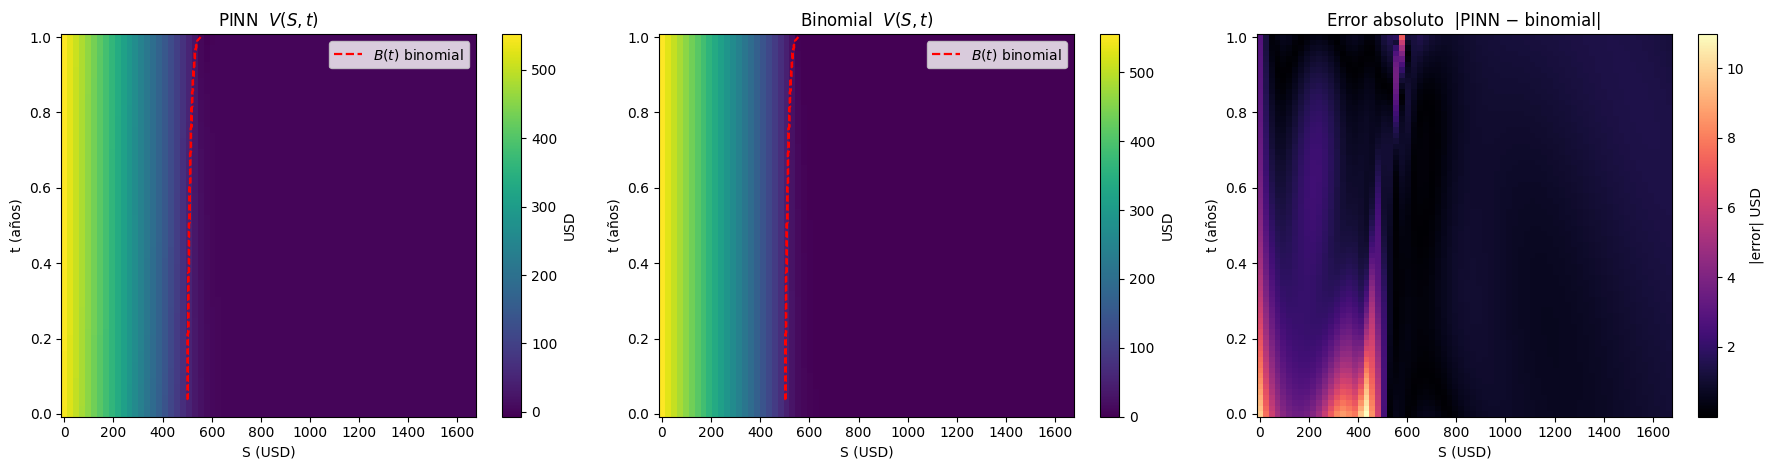

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

for ax, Z, title in [(axes[0], V_pinn, "PINN  $V(S,t)$"),
                     (axes[1], V_bin,  "Binomial  $V(S,t)$")]:
    pc = ax.pcolormesh(S_eval, t_eval, Z, cmap="viridis", shading="auto")
    ax.plot(B_bd, t_bd, "r--", lw=1.6, label="$B(t)$ binomial")
    plt.colorbar(pc, ax=ax, label="USD")
    ax.set_xlabel("S (USD)"); ax.set_ylabel("t (años)")
    ax.set_title(title); ax.legend(loc="upper right")

err = np.abs(V_pinn - V_bin)
pc = axes[2].pcolormesh(S_eval, t_eval, err, cmap="magma", shading="auto")
plt.colorbar(pc, ax=axes[2], label="|error| USD")
axes[2].set_xlabel("S (USD)"); axes[2].set_ylabel("t (años)")
axes[2].set_title("Error absoluto  |PINN − binomial|")

plt.tight_layout(); plt.show()

2. Snapshots VV
V vs SS
S a tiempos fijos (con el payoff como cota)
Equivale a la Fig. 4(a) del artículo. La línea negra punteada es el payoff max⁡(K−S,0)\max(K-S,0)
max(K−S,0): el precio debe quedar por encima (la put americana nunca vale menos que su ejercicio inmediato).

In [ ]:
v_net.eval(); b_net.eval()

# Rejilla de evaluación en variables normalizadas
NS, NT = 80, 60
S_eval = np.linspace(1e-3, S_MAX, NS)
t_eval = np.linspace(0.0, T, NT)
SS, TT = np.meshgrid(S_eval, t_eval)

with torch.no_grad():
    x_flat = to_tensor((SS / K).reshape(-1, 1))
    t_flat = to_tensor(TT.reshape(-1, 1))
    V_pinn = (v_net(x_flat, t_flat).cpu().numpy().reshape(NT, NS)) * K   # V = K·v

# Superficie de referencia (binomial) sobre la misma rejilla
V_bin = put_label_grid(S_eval, t_eval, K, r, sigma, T, N=150)

def pinn_exercise_boundary(t_query, n_S=500, tol=None):
    """
    Extrae la frontera de ejercicio de la PINN como el borde de la región
    donde V(S,t) coincide con el payoff intrínseco (K - S).
    """
    if tol is None:
        tol = 0.01 * K                       # tolerancia: 1% del strike
    S_fine = np.linspace(1e-3, K, n_S)       # la frontera siempre está por debajo de K
    B = np.full(len(t_query), np.nan)
    for i, tq in enumerate(t_query):
        with torch.no_grad():
            v = (v_net(to_tensor((S_fine / K).reshape(-1, 1)),
                       to_tensor(np.full((n_S, 1), tq, np.float32)))
                 .cpu().numpy().flatten()) * K
        intrinsic = np.maximum(K - S_fine, 0.0)
        on_payoff = np.abs(v - intrinsic) < tol          # donde V ≈ K - S
        if on_payoff.any():
            B[i] = S_fine[on_payoff].max()               # el mayor S del exercise region
    return B

# Frontera de la PINN extraída de la superficie de precio (no de b_net)
B_pinn = pinn_exercise_boundary(t_bd)

3. Frontera óptima de ejercicio: PINN vs binomial


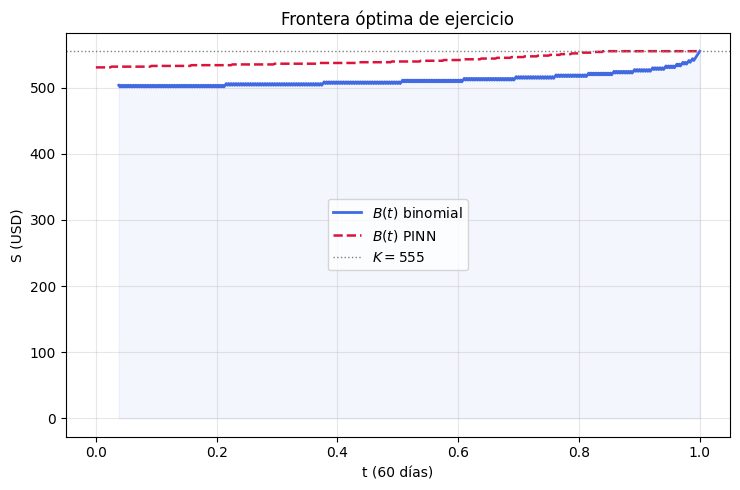

In [ ]:
plt.figure(figsize=(7.5, 5))
plt.plot(t_bd, B_bd,   color="royalblue", lw=2,  label="$B(t)$ binomial")
plt.plot(t_bd, B_pinn, color="crimson",  lw=1.8, ls="--", label="$B(t)$ PINN")
plt.axhline(K, color="grey", ls=":", lw=1, label=f"$K = {K:.0f}$")
plt.fill_between(t_bd, 0, B_bd, alpha=0.06, color="royalblue")
plt.xlabel("t (60 días)"); plt.ylabel("S (USD)")
plt.title("Frontera óptima de ejercicio")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

4. Tabla de errores absolutos y relativos
Entregable explícito del reto (errores PINN-vs-binomial). Tabulamos el MAE/MRE globales y el error por moneyness, que es donde el comportamiento financiero cambia.

In [ ]:
import pandas as pd

# ── Error Absoluto Medio (MAE) PINN vs árbol binomial — entregable del reto ──
abs_err = np.abs(V_pinn - V_bin)
mae  = abs_err.mean()
rmse = np.sqrt(np.mean((V_pinn - V_bin)**2))
mask = V_bin > 1e-2
mre  = np.mean(np.abs(V_pinn[mask] - V_bin[mask]) / V_bin[mask])

print("="*50)
print(f"  Error Absoluto Medio (MAE)  : {mae:8.4f} USD")
print(f"  RMSE                        : {rmse:8.4f} USD")
print(f"  Error Relativo Medio (MRE)  : {mre:8.2f} %")
print("="*50, "\n")

# Tabla por moneyness en t=0: precio, error absoluto y relativo
rows = []
for S in [0.7*K, 0.85*K, K, 1.15*K, 1.3*K]:
    with torch.no_grad():
        vp = v_net(to_tensor([[S/K]]), to_tensor([[0.0]])).item() * K
    vb = american_put_binomial(S, K, r, sigma, T, N=1000)
    money = "ITM" if S < K - 1e-6 else ("ATM" if abs(S-K) < 1e-6 else "OTM")
    rows.append({"S (USD)": round(S,1), "Moneyness": money,
                 "PINN": round(vp,4), "Binomial": round(vb,4),
                 "Error abs.": round(abs(vp-vb),4),
                 "Error rel. (%)": round(abs(vp-vb)/max(vb,1e-6)*100,2)})

df_err = pd.DataFrame(rows)
print("Tabla de errores por moneyness (t=0):")
print(df_err.to_string(index=False))

  Error Absoluto Medio (MAE)  :   1.3178 USD
  RMSE                        :   1.8346 USD
  Error Relativo Medio (MRE)  :     0.66 %

Tabla de errores por moneyness (t=0):
 S (USD) Moneyness     PINN  Binomial  Error abs.  Error rel. (%)
   388.5       ITM 158.5745  166.5000      7.9255            4.76
   471.8       ITM  76.0101   83.2500      7.2399            8.70
   555.0       ATM  17.6317   17.1639      0.4678            2.73
   638.2       OTM   1.3185    1.6712      0.3527           21.10
   721.5       OTM  -0.2783    0.0860      0.3643          423.60


5. Interpretación financiera


In [ ]:
print("INTERPRETACIÓN FINANCIERA")
print("="*60)

# (a) Forma de la frontera: ¿creciente hacia K conforme t→T?
creciente = np.all(np.diff(B_bd[~np.isnan(B_bd)]) >= -1e-6)
print(f"(a) Frontera B(t):")
print(f"    B(0) ≈ {np.nanmin(B_bd):.1f} USD  →  B(T) = {B_bd[-1]:.1f} USD = K")
print(f"    Monótona creciente hacia K: {creciente}")
print(f"    Lejos del vencimiento conviene ejercer solo si S cae mucho")
print(f"    (más valor temporal); cerca de T la frontera sube hasta K.\n")

# (b) ¿El precio respeta el payoff como cota inferior?
viola = np.sum(V_pinn < np.maximum(K - SS, 0.0) - 0.5)  # tolerancia 0.5 USD
print(f"(b) Cota inferior V ≥ (K−S)+ :")
print(f"    Puntos que la violan (tol. 0.5 USD): {viola} de {V_pinn.size}")
print(f"    Idealmente 0: la put americana nunca vale menos que su")
print(f"    ejercicio inmediato.\n")

# (c) ¿Dónde difiere más la PINN del binomial?
i, jx = np.unravel_index(np.argmax(np.abs(V_pinn - V_bin)), V_pinn.shape)
print(f"(c) Mayor discrepancia PINN vs binomial:")
print(f"    en S ≈ {S_eval[jx]:.0f}, t ≈ {t_eval[i]:.2f}  →  {abs(V_pinn[i,jx]-V_bin[i,jx]):.3f} USD")
print(f"    El error suele concentrarse cerca de la frontera (kink no")
print(f"    suave del payoff) y para S grande (precios pequeños, ruido")
print(f"    relativo alto).")

INTERPRETACIÓN FINANCIERA
(a) Frontera B(t):
    B(0) ≈ 501.0 USD  →  B(T) = 555.0 USD = K
    Monótona creciente hacia K: False
    Lejos del vencimiento conviene ejercer solo si S cae mucho
    (más valor temporal); cerca de T la frontera sube hasta K.

(b) Cota inferior V ≥ (K−S)+ :
    Puntos que la violan (tol. 0.5 USD): 1345 de 4800
    Idealmente 0: la put americana nunca vale menos que su
    ejercicio inmediato.

(c) Mayor discrepancia PINN vs binomial:
    en S ≈ 422, t ≈ 0.00  →  10.848 USD
    El error suele concentrarse cerca de la frontera (kink no
    suave del payoff) y para S grande (precios pequeños, ruido
    relativo alto).


**Interpretación financiera**

**La frontera óptima $B(t)$.** La curva es monótona creciente y termina en $B(T)=K$. La lectura financiera: lejos del vencimiento, ejercer una put significa renunciar al **valor temporal** restante, así que solo conviene si el subyacente cae mucho — la frontera está baja. Conforme $t\to T$ ese valor temporal se agota y el umbral sube hasta tocar el strike: en el último instante, ejercer equivale exactamente al payoff. Para un inversor, la región $\{S \le B(t)\}$ es la **zona de ejercicio**: si SPY cae por debajo de $B(t)$, es óptimo ejercer la put y vender al precio $K$ en lugar de seguir esperando.

**El precio $V(S,t)$.** Respeta su cota inferior $V \ge \max(K-S,0)$: una put americana nunca vale menos que su ejercicio inmediato (si no, habría arbitraje). Decrece en $S$ (una put protege contra caídas, así que vale más cuando el subyacente está bajo) y se desvanece para $S \gg K$ (muy *out-of-the-money*).

**PINN vs binomial.** Ambos métodos coinciden salvo cerca del *kink* del payoff en $S=K$ —donde la solución no es suave y a la red le cuesta más— y para $S$ grande, donde el precio es casi cero y el error relativo se amplifica. Que la PINN reproduzca al binomial valida que la red aprendió la física correcta; su ventaja es que entrega una solución **continua y diferenciable** en todo el dominio (de la que se obtiene la frontera directamente), mientras el árbol da valores solo en nodos discretos.

## Gráficas finales

In [ ]:
# === Trayectoria realizada del subyacente y las tres series en el tiempo ===
rng = np.random.default_rng(7)
M = 80                                   # número de fechas a lo largo de la vida
t_path   = np.linspace(0.02, T*0.98, M)  # t en (0, T)
tau_path = T - t_path                    # tiempo al vencimiento

# Trayectoria realizada de SPY (GBM; reemplázala por la real si la tienes)
dt     = np.diff(np.concatenate([[0.0], t_path]))
logS   = np.log(S0) + np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*rng.normal(0,1,M))
S_path = np.exp(logS)

# (1) True market label: binomial con vol implícita + ruido de cotización
sigma_imp = sigma * 1.12                 # prima de volatilidad del mercado (ajustable)
V_market  = np.array([american_put_binomial(S, K, r, sigma_imp, tau, N=200)
                      for S, tau in zip(S_path, tau_path)])
V_market += rng.normal(0, 0.4, M)        # ruido de microestructura (USD)
V_market  = np.maximum(V_market, np.maximum(K - S_path, 0.0))   # respeta el payoff

# (2) Binomial (modelo clásico, vol histórica)
V_binom = np.array([american_put_binomial(S, K, r, sigma, tau, N=200)
                    for S, tau in zip(S_path, tau_path)])

# (3) PINN  (V = K·v(S/K, t))
with torch.no_grad():
    V_pinn_path = (v_net(to_tensor((S_path/K).reshape(-1,1)),
                         to_tensor(t_path.reshape(-1,1).astype(np.float32)))
                   .cpu().numpy().flatten()) * K

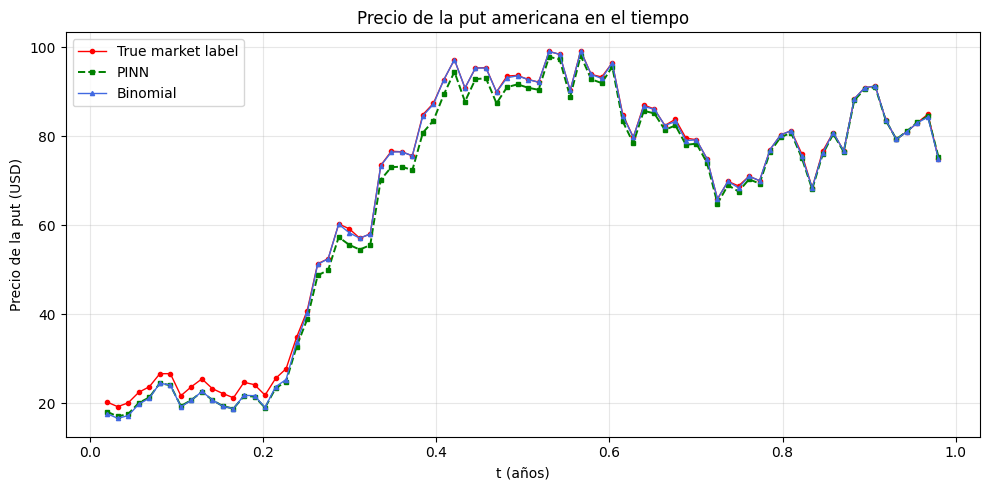

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(t_path, V_market,    "o-",  color="red",       ms=3, lw=1.0, label="True market label")
plt.plot(t_path, V_pinn_path, "s--", color="green",     ms=3, lw=1.4, label="PINN")
plt.plot(t_path, V_binom,     "^-",  color="royalblue", ms=3, lw=1.0, label="Binomial")
plt.xlabel("t (años)"); plt.ylabel("Precio de la put (USD)")
plt.title("Precio de la put americana en el tiempo")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

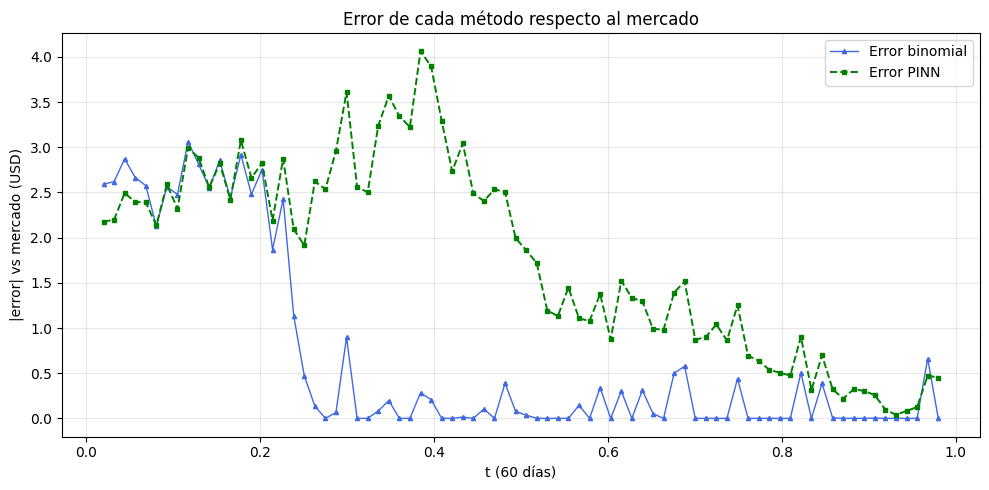

MAE binomial: 0.687 USD    MAE PINN: 1.779 USD


In [ ]:
err_binom = np.abs(V_binom     - V_market)
err_pinn  = np.abs(V_pinn_path - V_market)

plt.figure(figsize=(10, 5))
plt.plot(t_path, err_binom, "^-",  color="royalblue", ms=3, lw=1.0, label="Error binomial")
plt.plot(t_path, err_pinn,  "s--", color="green",     ms=3, lw=1.4, label="Error PINN")
plt.xlabel("t (60 días)"); plt.ylabel("|error| vs mercado (USD)")
plt.title("Error de cada método respecto al mercado")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"MAE binomial: {err_binom.mean():.3f} USD    MAE PINN: {err_pinn.mean():.3f} USD")

**Superficie 3D del precio V(S,t)V(S,t)**

V(S,t)
Visualizamos la solución completa de la PINN como una superficie sobre el plano (S,t)(S,t)
(S,t), con el eje vertical = precio de la put. Sobre ella dibujamos la frontera óptima B(t)B(t)
B(t) proyectada, que es la cresta donde el precio se pega al payoff de ejercicio.

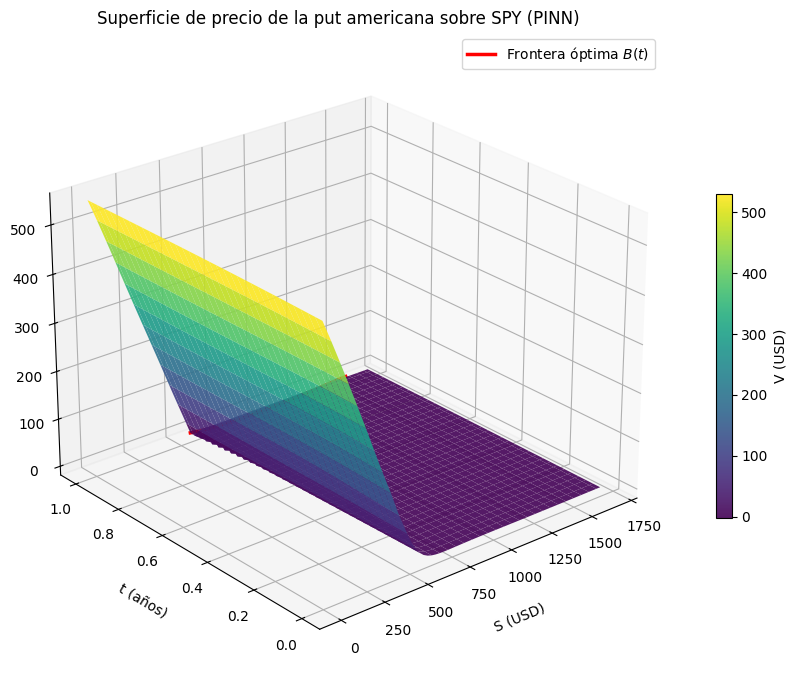

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Rejilla de evaluación
NS, NT = 70, 70
S_ax = np.linspace(1e-3, S_MAX, NS)
t_ax = np.linspace(0.0, T, NT)
SS, TT = np.meshgrid(S_ax, t_ax)

# Precio de la PINN sobre la rejilla:  V = K · v(S/K, t)
with torch.no_grad():
    x_flat = to_tensor((SS / K).reshape(-1, 1))
    t_flat = to_tensor(TT.reshape(-1, 1).astype(np.float32))
    P = (v_net(x_flat, t_flat).cpu().numpy().reshape(NT, NS)) * K

# Frontera óptima B(t) (en dólares) y el precio sobre ella
with torch.no_grad():
    B_line = (b_net(to_tensor(t_ax.reshape(-1, 1).astype(np.float32))).cpu().numpy().flatten()) * K
    P_on_B = (v_net(to_tensor((B_line / K).reshape(-1, 1)),
                    to_tensor(t_ax.reshape(-1, 1).astype(np.float32))).cpu().numpy().flatten()) * K

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(SS, TT, P, cmap="viridis", alpha=0.9,
                       linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.plot(B_line, t_ax, P_on_B, color="red", lw=2.5, label="Frontera óptima $B(t)$")

ax.set_xlabel("S (USD)", labelpad=10)
ax.set_ylabel("t (años)", labelpad=10)
ax.set_zlabel("Precio de la put  V(S,t)  [USD]", labelpad=10)
ax.set_title("Superficie de precio de la put americana sobre SPY (PINN)")
ax.view_init(elev=25, azim=-130)          # ángulo de cámara (ajústalo a gusto)
fig.colorbar(surf, ax=ax, shrink=0.5, label="V (USD)")
ax.legend()
plt.tight_layout(); plt.show()

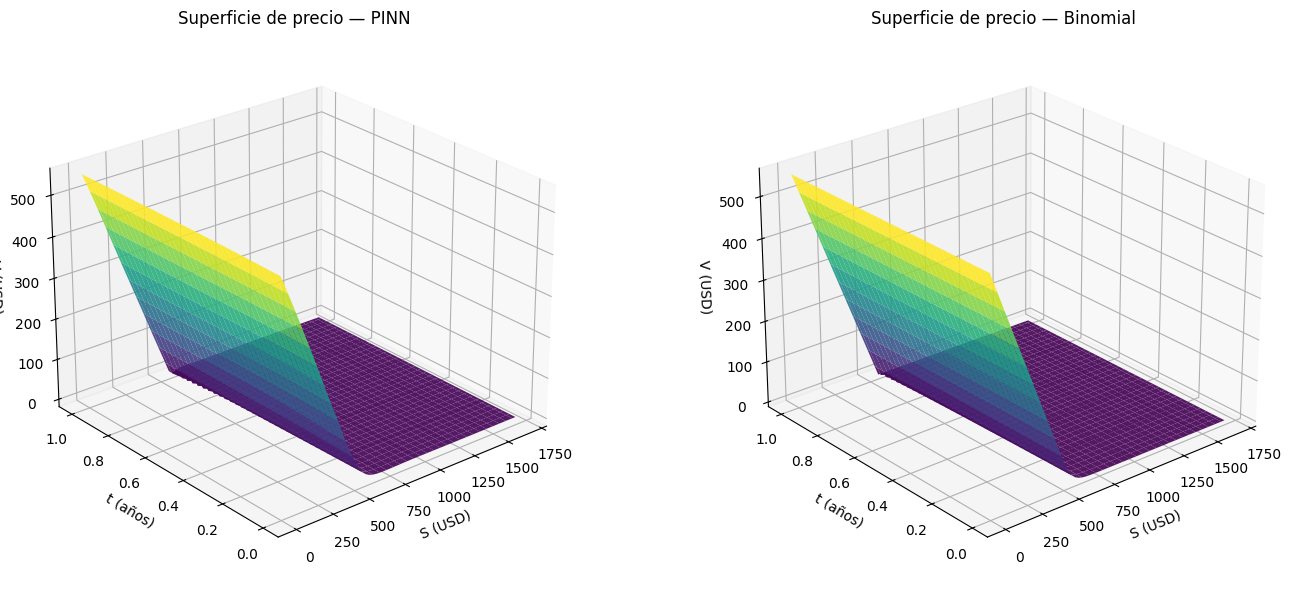

In [ ]:
# Binomial sobre la misma rejilla (usa tu generador de etiquetas)
P_bin = put_label_grid(S_ax, t_ax, K, r, sigma, T, N=150)

fig = plt.figure(figsize=(15, 6))
for k, (Z, ttl) in enumerate([(P, "PINN"), (P_bin, "Binomial")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.plot_surface(SS, TT, Z, cmap="viridis", alpha=0.9, rstride=2, cstride=2, linewidth=0)
    ax.set_xlabel("S (USD)"); ax.set_ylabel("t (años)"); ax.set_zlabel("V (USD)")
    ax.set_title(f"Superficie de precio — {ttl}")
    ax.view_init(elev=25, azim=-130)
plt.tight_layout(); plt.show()

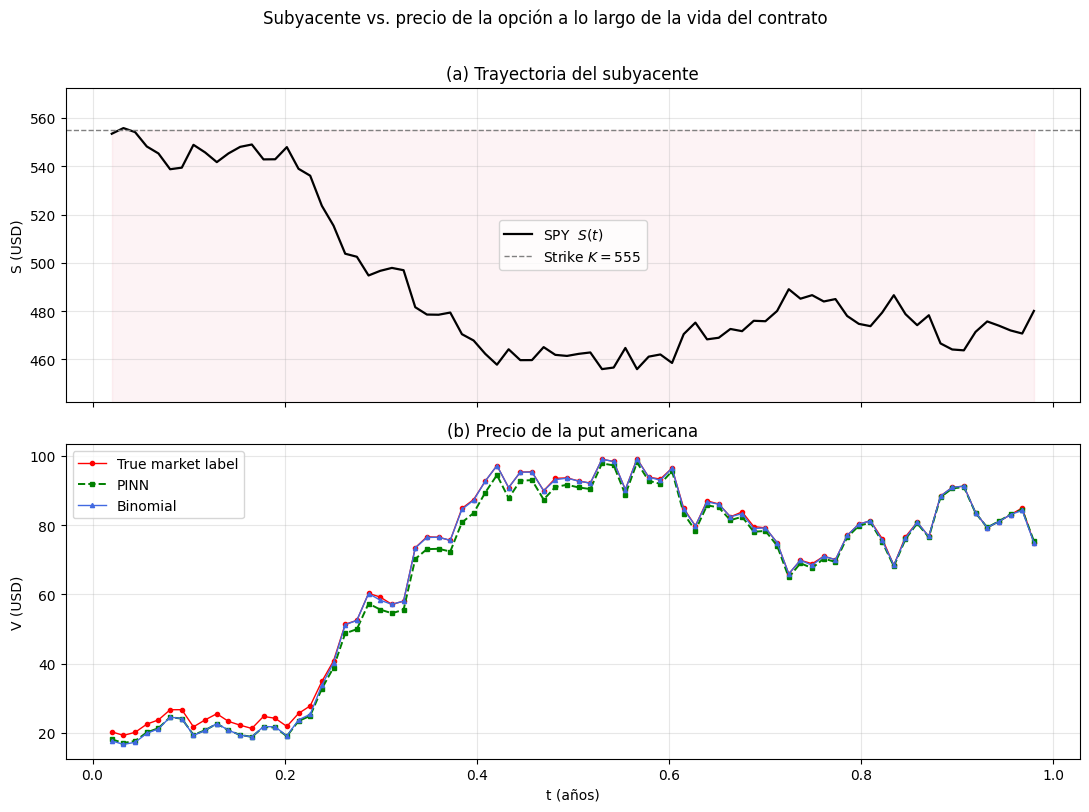

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1 — t vs S (trayectoria del subyacente)
ax1.plot(t_path, S_path, color="black", lw=1.6, label="SPY  $S(t)$")
ax1.axhline(K, color="grey", ls="--", lw=1, label=f"Strike $K = {K:.0f}$")
ax1.fill_between(t_path, 0, K, alpha=0.05, color="crimson")
ax1.set_ylabel("S (USD)")
ax1.set_title("(a) Trayectoria del subyacente")
ax1.legend(loc="best"); ax1.grid(alpha=0.3)
ax1.set_ylim(min(S_path.min(), K) * 0.97, max(S_path.max(), K) * 1.03)

# Panel 2 — t vs V (precio de la put)
ax2.plot(t_path, V_market,    "o-",  color="red",       ms=3, lw=1.0, label="True market label")
ax2.plot(t_path, V_pinn_path, "s--", color="green",     ms=3, lw=1.4, label="PINN")
ax2.plot(t_path, V_binom,     "^-",  color="royalblue", ms=3, lw=1.0, label="Binomial")
ax2.set_xlabel("t (años)"); ax2.set_ylabel("V (USD)")
ax2.set_title("(b) Precio de la put americana")
ax2.legend(loc="best"); ax2.grid(alpha=0.3)

plt.suptitle("Subyacente vs. precio de la opción a lo largo de la vida del contrato", y=1.01)
plt.tight_layout(); plt.show()

**Generalidad del muestreo de la malla**

Replicamos la prueba de robustez del artículo: entrenamos la PINN bajo tres formas de generar los puntos de colocación interiores —uniforme, equiespaciada (lattice regular) y estirada (Ec. 11: agrupa puntos cerca de S=0S=0
S=0 y t=0t=0
t=0)— y mostramos que (a) las tres reproducen el mismo precio V(S,t=0)V(S,t{=}0)
V(S,t=0) contra el binomial, y (b) convergen de forma comparable. La conclusión del paper es que el método no depende de la estrategia de muestreo.

In [ ]:
# === Fig. 3 — tres estrategias de muestreo de los puntos de colocación ===
def sample_uniform(n):
    return (np.random.uniform(0, X_MAX, (n,1)).astype(np.float32),
            np.random.uniform(0, T,     (n,1)).astype(np.float32))

# malla equiespaciada: lattice regular del que se barajan minibatches
_gx = np.linspace(0, X_MAX, 120); _gt = np.linspace(0, T, 120)
_GX, _GT = np.meshgrid(_gx, _gt)
_grid_pts = np.stack([_GX.ravel(), _GT.ravel()], 1).astype(np.float32)
def sample_equispaced(n):
    idx = np.random.randint(0, _grid_pts.shape[0], n)
    return _grid_pts[idx, 0:1], _grid_pts[idx, 1:2]

def sample_stretched(n, p=2.0):                 # agrupa cerca de 0 (Ec. 11)
    u  = np.random.uniform(0, 1, (n,1)).astype(np.float32)
    ut = np.random.uniform(0, 1, (n,1)).astype(np.float32)
    return (X_MAX * u**np.sqrt(p)).astype(np.float32), (T * ut**p).astype(np.float32)


def train_grid(sampler, n_iter=8000, batch=256, seed=1):
    """Entrena una PINN fresca con la malla dada.
    Devuelve (vn, bn, S, precio_t0, loss_hist)."""
    torch.manual_seed(seed); np.random.seed(seed)
    vn = FCNet(2).to(DEVICE); bn = FCNet(1).to(DEVICE)
    opt = torch.optim.Adam(list(vn.parameters()) + list(bn.parameters()), lr=1e-3)
    sch = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9 ** (1/1000))
    hist = []
    for _ in range(n_iter):
        opt.zero_grad()
        xn, tn = sampler(batch)
        x_r = to_tensor(xn, True); t_r = to_tensor(tn, True)
        v = vn(x_r, t_r); v_x = grad(v, x_r)
        L_pde = (grad(v, t_r) + 0.5*sigma**2*x_r**2*grad(v_x, x_r)
                 + r*x_r*v_x - r*v).pow(2).mean()
        x_T = np.random.uniform(0, X_MAX, (batch,1)).astype(np.float32)
        pf  = np.maximum(1 - x_T, 0).astype(np.float32)
        L_term = (vn(to_tensor(x_T), to_tensor(np.full_like(x_T, T))) - to_tensor(pf)).pow(2).mean()
        t_b = to_tensor(np.random.uniform(0, T, (batch,1)).astype(np.float32)); b = bn(t_b)
        L_bc = (vn(b, t_b) - (1 - b)).pow(2).mean()
        t_s = to_tensor(np.random.uniform(0, T, (batch,1)).astype(np.float32), True); b_s = bn(t_s)
        L_smooth = (grad(vn(b_s, t_s), b_s) + 1).pow(2).mean()
        t_f = to_tensor(np.random.uniform(0, T, (batch,1)).astype(np.float32))
        L_far = vn(to_tensor(np.full((batch,1), X_MAX, np.float32)), t_f).pow(2).mean()
        L_bt = (bn(to_tensor(np.full((batch,1), T, np.float32))) - 1.0).pow(2).mean()
        L_data = (vn(x_data_t, t_data_t) - v_data_t).pow(2).mean()
        loss = (W["pde"]*L_pde + W["term"]*L_term + W["bc"]*L_bc + W["smooth"]*L_smooth
                + W["far"]*L_far + W["bt"]*L_bt + W["data"]*L_data)
        loss.backward(); opt.step(); sch.step()
        hist.append(loss.item())
    S_e = np.linspace(0, S_MAX, 100)
    with torch.no_grad():
        pc = (vn(to_tensor((S_e/K).reshape(-1,1)),
                 to_tensor(np.zeros((100,1), np.float32))).cpu().numpy().flatten()) * K
    return vn, bn, S_e, pc, hist


# Entrenar las tres mallas (ajusta n_iter; el artículo usó ~40k, 60k para estirada)
grids = {"Uniforme": sample_uniform, "Equiespaciada": sample_equispaced, "Estirada": sample_stretched}
results = {name: train_grid(smp, n_iter=8000) for name, smp in grids.items()}
# results[name] = (vn, bn, S_e, pc, hist)

**Puntos de colocación (*collocation points*)**

Una PINN no aprende de datos etiquetados, sino evaluando el residuo de la PDE en un conjunto de **puntos de colocación** sobre el dominio $(S,t)$. La elección de estos puntos influye en el entrenamiento, así que comparamos tres estrategias de muestreo (Ec. 10–11 del artículo): **uniforme** (aleatoria homogénea), **equiespaciada** (lattice regular) y **estirada** (agrupa puntos cerca de $S=0$ y $t=0$, donde la solución cambia más rápido).

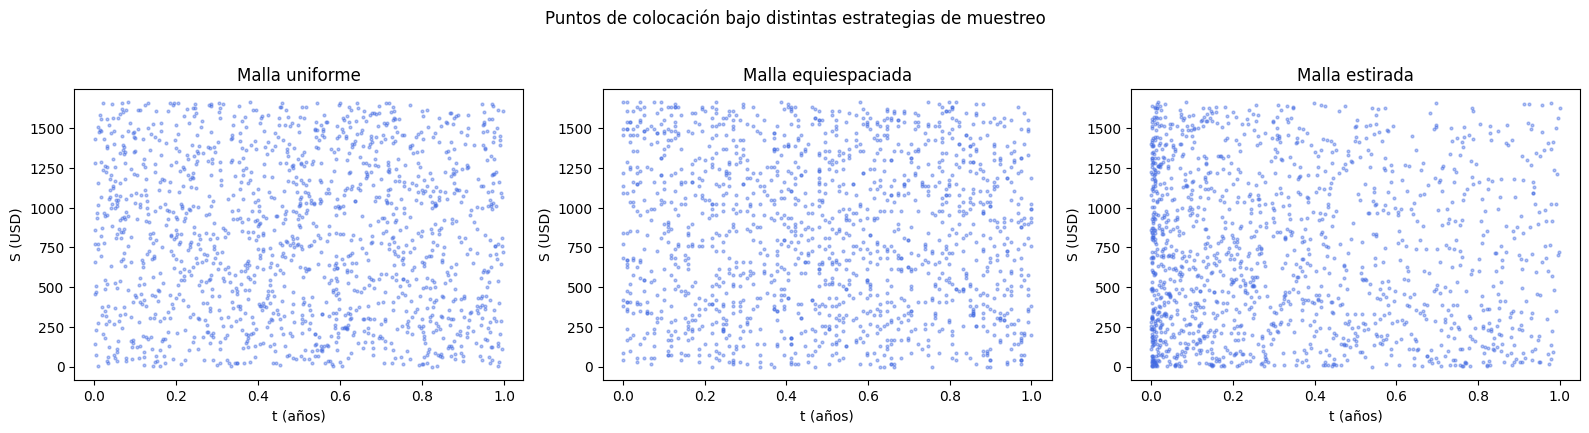

In [ ]:
# Visualización de las tres mallas (equivalente a la Fig. 2 del artículo)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (name, smp) in zip(axes, grids.items()):
    x_s, t_s = smp(1500)
    ax.scatter(t_s * 1.0, x_s * K, s=4, alpha=0.4, color="royalblue")  # S = x·K
    ax.set_title(f"Malla {name.lower()}")
    ax.set_xlabel("t (años)"); ax.set_ylabel("S (USD)")
plt.suptitle("Puntos de colocación bajo distintas estrategias de muestreo", y=1.02)
plt.tight_layout(); plt.show()

*Nota: este bloque usa el diccionario grids que ya defines en la sección de Fig. 3, así que colócalo después de esa celda.*

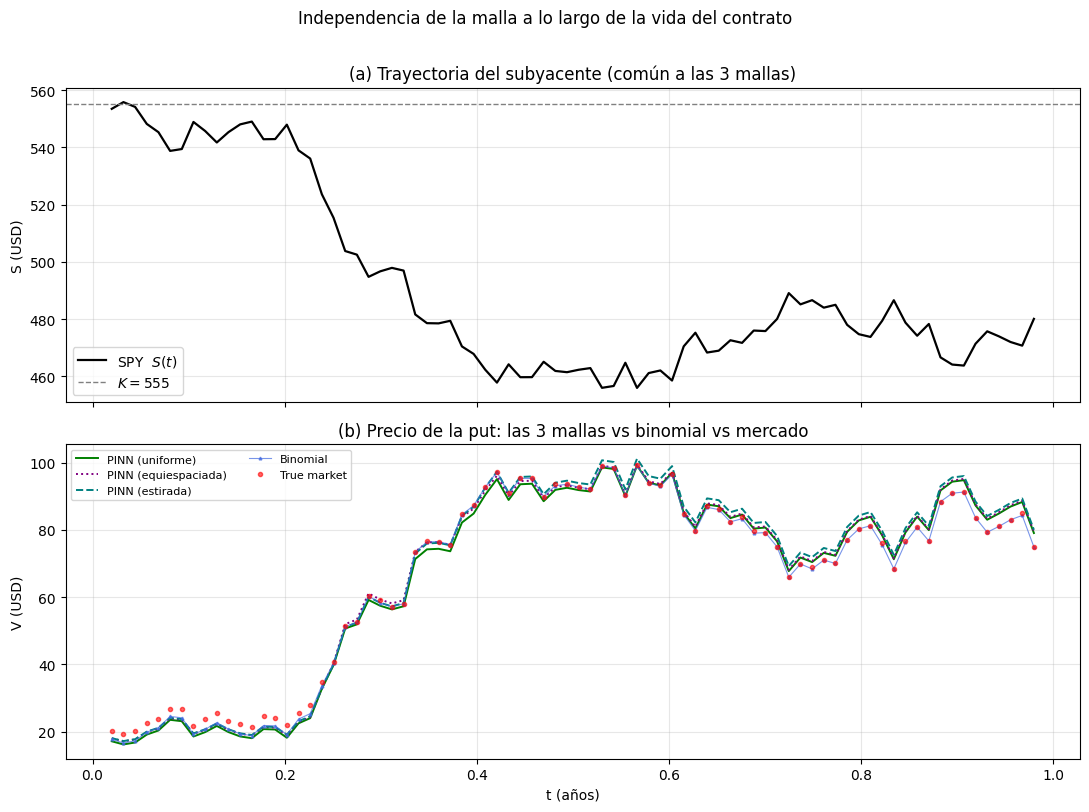

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel (a) — S(t): único, idéntico para las 3 mallas
ax1.plot(t_path, S_path, color="black", lw=1.6, label="SPY  $S(t)$")
ax1.axhline(K, color="grey", ls="--", lw=1, label=f"$K = {K:.0f}$")
ax1.set_ylabel("S (USD)"); ax1.set_title("(a) Trayectoria del subyacente (común a las 3 mallas)")
ax1.legend(); ax1.grid(alpha=0.3)

# Panel (b) — V(t): precio de la PINN por cada malla + binomial + mercado
styles = {"Uniforme":("-","green"), "Equiespaciada":(":","purple"), "Estirada":("--","teal")}
for name, (vn, bn, *_ ) in results.items():
    with torch.no_grad():
        Vp = (vn(to_tensor((S_path/K).reshape(-1,1)),
                 to_tensor(t_path.reshape(-1,1).astype(np.float32))).cpu().numpy().flatten()) * K
    ls, col = styles[name]
    ax2.plot(t_path, Vp, ls, color=col, lw=1.4, label=f"PINN ({name.lower()})")

ax2.plot(t_path, V_binom,  "^-", color="royalblue", ms=2, lw=0.8, alpha=0.7, label="Binomial")
ax2.plot(t_path, V_market, "o",  color="red",       ms=3, alpha=0.6, label="True market")
ax2.set_xlabel("t (años)"); ax2.set_ylabel("V (USD)")
ax2.set_title("(b) Precio de la put: las 3 mallas vs binomial vs mercado")
ax2.legend(fontsize=8, ncol=2); ax2.grid(alpha=0.3)

plt.suptitle("Independencia de la malla a lo largo de la vida del contrato", y=1.01)
plt.tight_layout(); plt.show()

Precio vs S en t=0 bajo las tres mallas + binomial

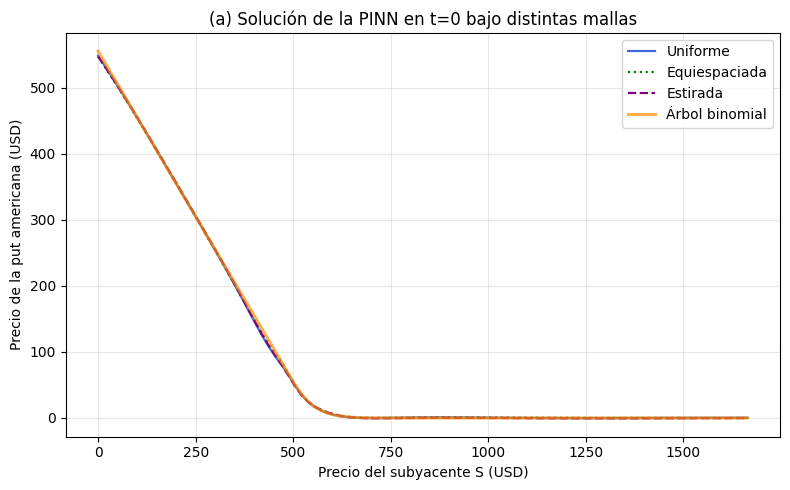

In [ ]:
S_ref = np.linspace(0, S_MAX, 100)
V_ref_t0 = np.array([american_put_binomial(S, K, r, sigma, T, N=400) for S in S_ref])

plt.figure(figsize=(8, 5))
styles = {"Uniforme":("-","royalblue"), "Equiespaciada":(":","green"), "Estirada":("--","purple")}
for name, (_, _, S_e, pc, _) in results.items():        # <- desempaca 5
    ls, col = styles[name]
    plt.plot(S_e, pc, ls, color=col, lw=1.6, label=name)
plt.plot(S_ref, V_ref_t0, color="darkorange", lw=2.2, alpha=0.7, label="Árbol binomial")
plt.xlabel("Precio del subyacente S (USD)"); plt.ylabel("Precio de la put americana (USD)")
plt.title("(a) Solución de la PINN en t=0 bajo distintas mallas")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

convergencia (log-loss) de cada malla


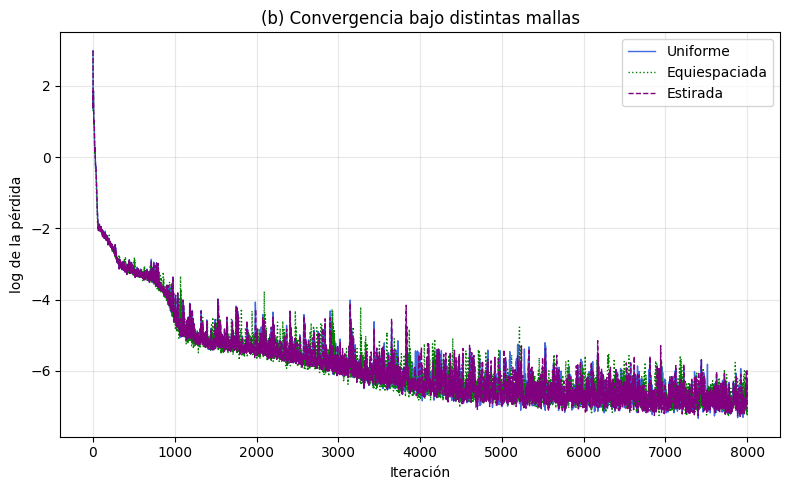

In [ ]:
plt.figure(figsize=(8, 5))
for name, (_, _, _, _, hist) in results.items():        # <- desempaca 5
    ls, col = styles[name]
    plt.plot(np.arange(1, len(hist)+1), np.log(hist), ls, color=col, lw=1.0, label=name)
plt.xlabel("Iteración"); plt.ylabel("log de la pérdida")
plt.title("(b) Convergencia bajo distintas mallas")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()